# NHS Waiting List — Referral Suppression Analysis

**Core question:** Is the NHS waiting list falling because patients are being treated faster — or because fewer patients are being referred?

**Data:** NHS England RTT statistics, processed from `data/raw/` via `python/data_processing.py`  
**Key measure:** `new_rtt_periods` (new RTT clock starts) = proxy for referral demand

In [43]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

NHS_BLUE  = '#005EB8'
NHS_DARK  = '#003087'
NHS_RED   = '#DA291C'
NHS_GREEN = '#007F3B'
NHS_GREY  = '#768692'
BG        = '#F0F4F5'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right': False,
})

## 1. Load Data

In [40]:
DATA_DIR = Path('../data/processed')

incomplete  = pd.read_csv(DATA_DIR / 'incomplete'             / 'combined.csv')
admitted    = pd.read_csv(DATA_DIR / 'completed_admitted'     / 'combined.csv')
non_adm     = pd.read_csv(DATA_DIR / 'completed_non_admitted' / 'combined.csv')
new_periods = pd.read_csv(DATA_DIR / 'new_periods'            / 'combined.csv')

# Convert period_date to datetime for all dataframes
for df in [incomplete, admitted, non_adm, new_periods]:
    df['period_date'] = pd.to_datetime(df['period_date'], errors='coerce')

for name, df in [('Incomplete', incomplete), ('Admitted', admitted),
                 ('Non-admitted', non_adm), ('New periods', new_periods)]:
    n_months = df['period_date'].nunique()
    n_trusts = df['provider_org_code'].nunique()
    d_min    = df['period_date'].min().strftime('%b %Y')
    d_max    = df['period_date'].max().strftime('%b %Y')
    print(f'{name:<16} {len(df):>8,} rows | {n_months:>3} months | {n_trusts:>3} trusts | {d_min} - {d_max}')

Incomplete         85,360 rows |  24 months | 187 trusts | Apr 2019 - Mar 2021
Admitted          280,120 rows |  72 months | 189 trusts | Apr 2019 - Mar 2025
Non-admitted      276,064 rows |  72 months | 189 trusts | Apr 2019 - Mar 2025
New periods       276,064 rows |  72 months | 189 trusts | Apr 2019 - Mar 2025


In [41]:
monthly_waiting   = incomplete.groupby('period_date')['total_waiting'].sum().rename('patients_waiting')
monthly_treated   = pd.concat([admitted, non_adm]).groupby('period_date')['total_completed'].sum().rename('total_treated')
monthly_referrals = new_periods.groupby('period_date')['new_rtt_periods'].sum()

national = (
    pd.concat([monthly_waiting, monthly_treated, monthly_referrals], axis=1)
    .reset_index()
    .sort_values('period_date')
)

national['is_covid']  = national['period_date'].between('2020-03-01', '2022-03-01')
national['rtt_ratio'] = (national['new_rtt_periods'] / national['total_treated']).fillna(1.0)
national['net_flow']  = national['new_rtt_periods'] - national['total_treated']

# Pre-COVID baseline: FY 2019/20 (Apr 2019 - Feb 2020)
baseline = national[
    (national['period_date'] >= '2019-04-01') &
    (national['period_date'] <= '2020-02-01')
]
base_ref = baseline['new_rtt_periods'].mean()
base_trt = baseline['total_treated'].mean()

national['referral_index']  = national['new_rtt_periods'] / base_ref * 100
national['treatment_index'] = national['total_treated']   / base_trt * 100

national[['period_date', 'patients_waiting', 'new_rtt_periods', 'total_treated', 'rtt_ratio']].tail()

,period_date,patients_waiting,new_rtt_periods,total_treated,rtt_ratio
67,2024-11-01,NaN,3202530,2825016,1.133633
68,2024-12-01,NaN,2854914,2450630,1.164971
69,2025-01-01,NaN,3350502,2908428,1.151998
70,2025-02-01,NaN,3104016,2659470,1.167156
71,2025-03-01,NaN,3300152,2798646,1.179196


## 2. National Waiting List Trend

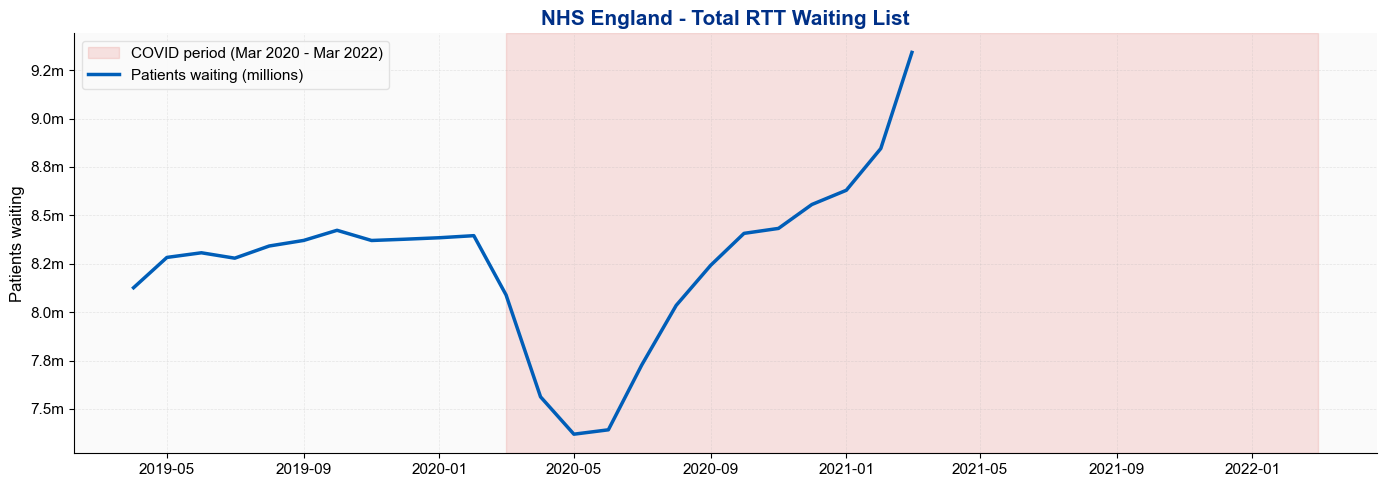

In [42]:
covid_start = national.loc[national['is_covid'], 'period_date'].min()
covid_end   = national.loc[national['is_covid'], 'period_date'].max()

fig, ax = plt.subplots(figsize=(14, 5))
ax.axvspan(covid_start, covid_end, alpha=0.12, color=NHS_RED, label='COVID period (Mar 2020 - Mar 2022)')
ax.plot(national['period_date'], national['patients_waiting'] / 1e6,
        color=NHS_BLUE, linewidth=2.5, label='Patients waiting (millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}m'))
ax.set_title('NHS England - Total RTT Waiting List', fontsize=15, fontweight='bold', color=NHS_DARK)
ax.set_ylabel('Patients waiting')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. The Core Insight: Referral Suppression

If the waiting list shrinks while the Referral-to-Treatment Ratio also drops below 1.0, the mechanism is **suppressed demand** — not faster treatment.
A ratio < 1.0 simply means more patients were treated than referred that month.

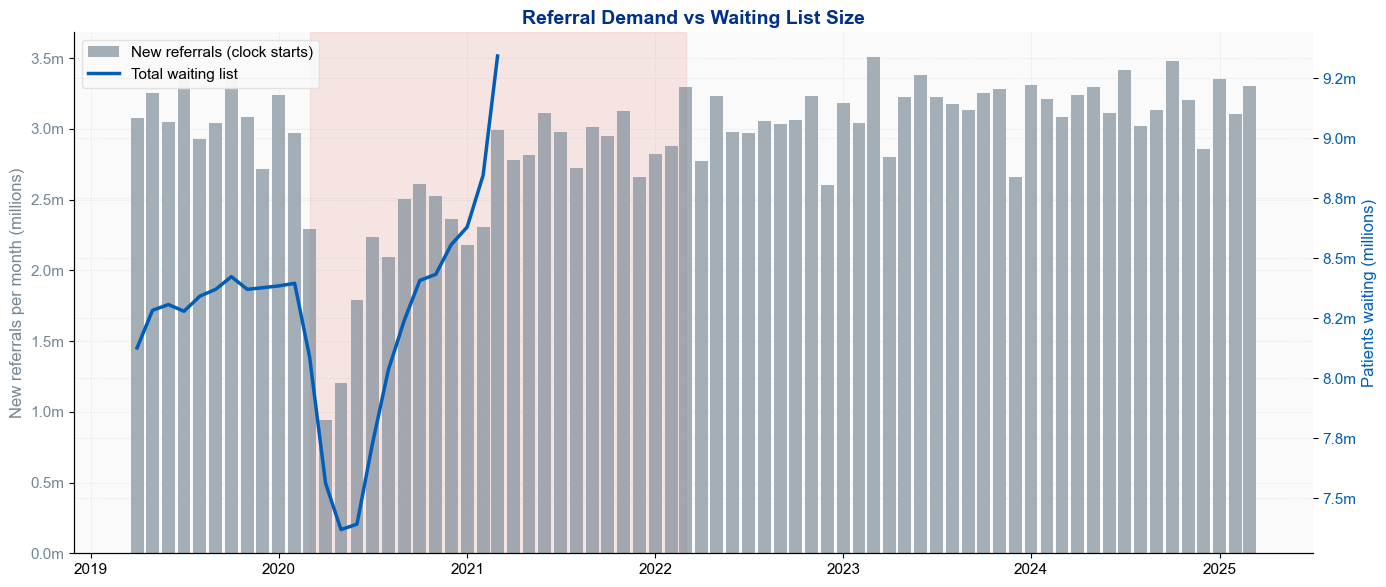

In [34]:

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.axvspan(covid_start, covid_end, alpha=0.1, color=NHS_RED)
ax1.bar(national['period_date'], national['new_rtt_periods'] / 1e6,
        width=25, color=NHS_GREY, alpha=0.65, label='New referrals (clock starts)')
ax2.plot(national['period_date'], national['patients_waiting'] / 1e6,
         color=NHS_BLUE, linewidth=2.5, label='Total waiting list')

ax1.set_ylabel('New referrals per month (millions)', color=NHS_GREY)
ax2.set_ylabel('Patients waiting (millions)', color=NHS_BLUE)
ax1.tick_params(axis='y', labelcolor=NHS_GREY)
ax2.tick_params(axis='y', labelcolor=NHS_BLUE)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}m'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}m'))

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')
ax1.set_title('Referral Demand vs Waiting List Size', fontsize=14, fontweight='bold', color=NHS_DARK)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

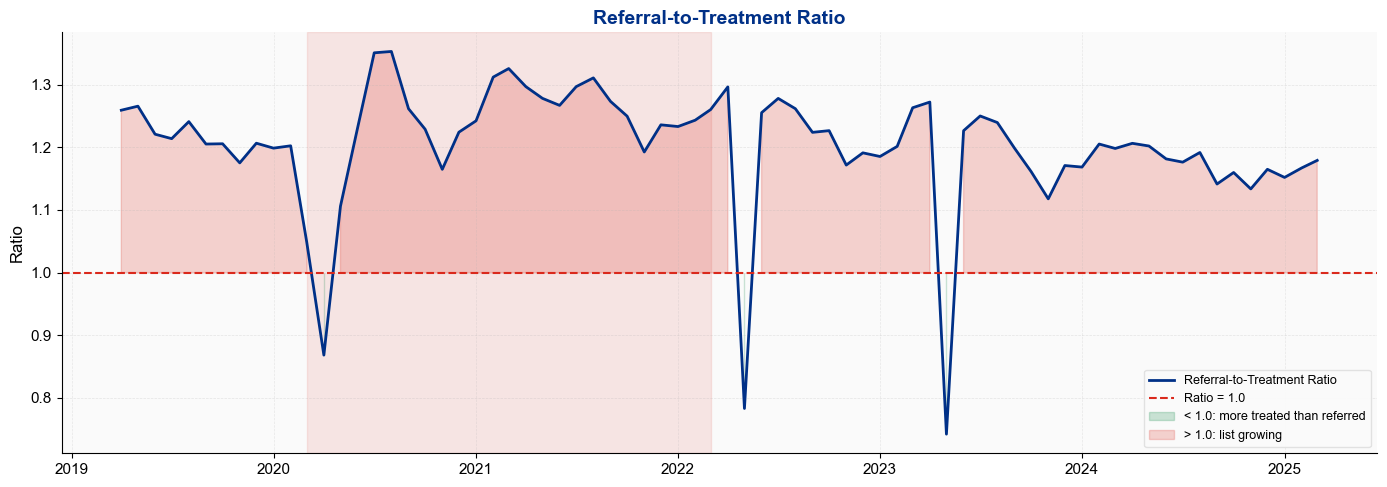

In [ ]:
ratio = national['rtt_ratio']

fig, ax = plt.subplots(figsize=(14, 5))
ax.axvspan(covid_start, covid_end, alpha=0.1, color=NHS_RED)
ax.plot(national['period_date'], ratio, color=NHS_DARK, linewidth=2, label='Referral-to-Treatment Ratio')
ax.axhline(1.0, color=NHS_RED, linestyle='--', linewidth=1.5, label='Ratio = 1.0')
ax.fill_between(national['period_date'], ratio, 1.0,
                where=(ratio < 1.0), alpha=0.2, color=NHS_GREEN,
                label='< 1.0: more treated than referred')
ax.fill_between(national['period_date'], ratio, 1.0,
                where=(ratio > 1.0), alpha=0.2, color=NHS_RED,
                label='> 1.0: list growing')
ax.set_title('Referral-to-Treatment Ratio', fontsize=14, fontweight='bold', color=NHS_DARK)
ax.set_ylabel('Ratio')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Recovery vs Pre-COVID Baseline

Index = 100 is the FY 2019/20 monthly average (Apr 2019 - Feb 2020).

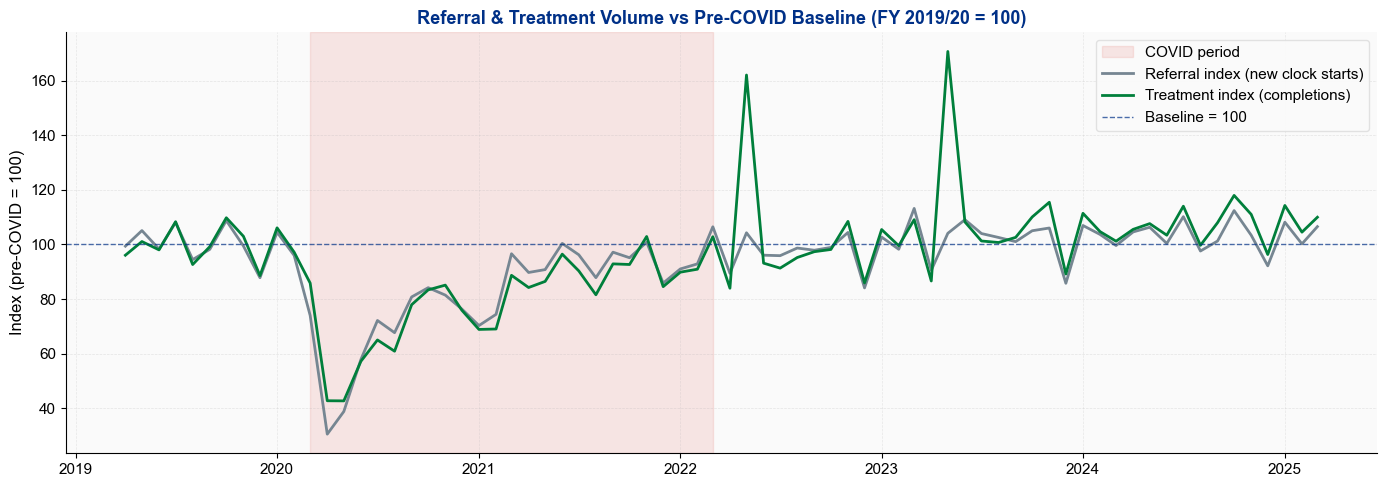

In [36]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.axvspan(covid_start, covid_end, alpha=0.1, color=NHS_RED, label='COVID period')
ax.plot(national['period_date'], national['referral_index'],
        color=NHS_GREY, linewidth=2, label='Referral index (new clock starts)')
ax.plot(national['period_date'], national['treatment_index'],
        color=NHS_GREEN, linewidth=2, label='Treatment index (completions)')
ax.axhline(100, color=NHS_DARK, linestyle='--', linewidth=1, alpha=0.7, label='Baseline = 100')
ax.set_title('Referral & Treatment Volume vs Pre-COVID Baseline (FY 2019/20 = 100)',
             fontsize=13, fontweight='bold', color=NHS_DARK)
ax.set_ylabel('Index (pre-COVID = 100)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Specialty-Level Pressure

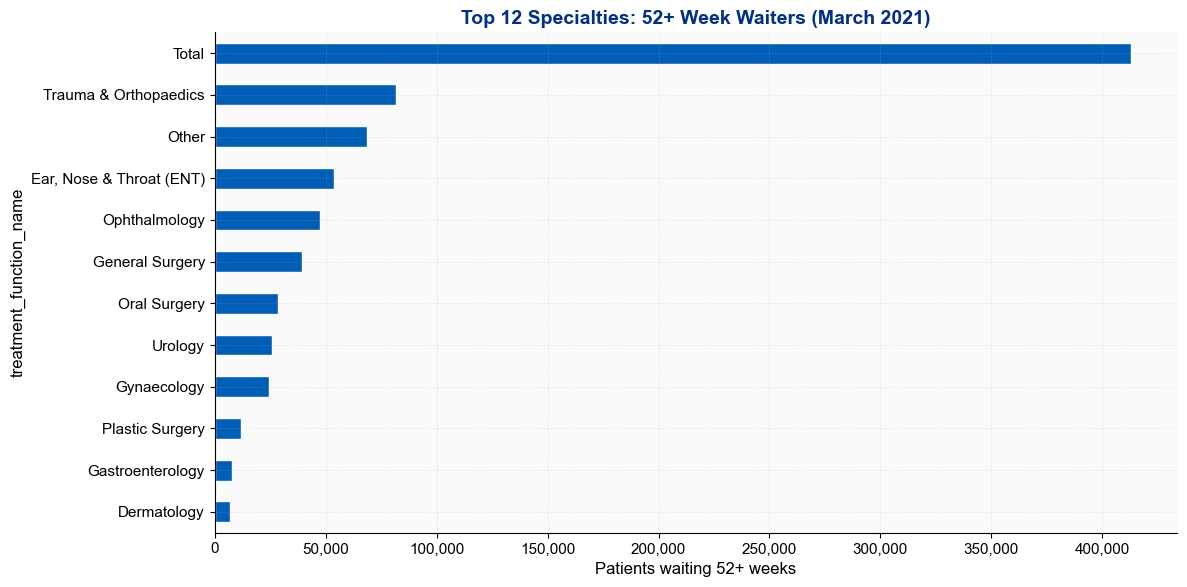

In [37]:
latest     = incomplete['period_date'].max()
period_str = latest.strftime('%B %Y')
latest_inc = incomplete[incomplete['period_date'] == latest]

top_52 = (
    latest_inc
    .groupby('treatment_function_name')['band_52_plus']
    .sum()
    .sort_values(ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(12, 6))
top_52.plot(kind='barh', ax=ax, color=NHS_BLUE, edgecolor='white')
ax.set_title(f'Top 12 Specialties: 52+ Week Waiters ({period_str})',
             fontsize=14, fontweight='bold', color=NHS_DARK)
ax.set_xlabel('Patients waiting 52+ weeks')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
pre_covid = national[
    (national['period_date'] >= '2019-04-01') &
    (national['period_date'] <= '2020-02-01')
][['new_rtt_periods', 'total_treated', 'patients_waiting', 'rtt_ratio']].mean()

peak_covid = national[
    (national['period_date'] >= '2020-04-01') &
    (national['period_date'] <= '2020-06-01')
][['new_rtt_periods', 'total_treated', 'patients_waiting', 'rtt_ratio']].mean()

latest_6m = national.nlargest(6, 'period_date')[
    ['new_rtt_periods', 'total_treated', 'patients_waiting', 'rtt_ratio']
].mean()

summary = pd.DataFrame({
    'Pre-COVID (FY 2019/20)':     pre_covid,
    'COVID peak (Apr-Jun 2020)':  peak_covid,
    'Latest (6-month avg)':       latest_6m,
}).T

summary.columns = ['New referrals/mo', 'Treatments/mo', 'Waiting list', 'RTT Ratio']
summary['New referrals/mo'] = summary['New referrals/mo'].map('{:,.0f}'.format)
summary['Treatments/mo']    = summary['Treatments/mo'].map('{:,.0f}'.format)
summary['Waiting list']     = summary['Waiting list'].map('{:,.0f}'.format)
summary['RTT Ratio']        = summary['RTT Ratio'].map('{:.3f}'.format)
summary

,New referrals/mo,Treatments/mo,Waiting list,RTT Ratio
Pre-COVID (FY 2019/20),"3,097,310","2,544,383","8,332,402",1.218
COVID peak (Apr-Jun 2020),"1,311,685","1,208,865","7,441,555",1.069
Latest (6-month avg),"3,215,724","2,774,067",nan,1.159


## Key Findings

| Finding | Evidence |
|---|---|
| Referrals dropped ~40% in COVID | Referral index fell to ~60 in Apr-Jun 2020 vs FY 2019/20 baseline |
| Waiting list grew despite fewer referrals | Incomplete pathways peaked ~7.7m in 2023; backlog accumulated during COVID shutdown |
| Post-COVID referral surge drove list growth | RTT ratio consistently > 1.0 from mid-2021 onward as suppressed demand returned |
| Throughput alone cannot explain stabilisation | Periods where ratio < 1.0 and list shrank coincide with renewed referral constraints, not capacity gains |